# Notebook 03 — Graph Topology

**Milestone 2, Step 3**

Builds and visualizes the 53-joint graph used by ST-GCN.

### Joint layout
| Indices | Part | Count |
|---------|------|-------|
| 0–20    | Left hand (wrist + 5 fingers × 4 joints) | 21 |
| 21–41   | Right hand (same) | 21 |
| 42–52   | Upper body (nose, ears, shoulders, elbows, wrists, hips) | 11 |

### Spatial edges
Edges follow **natural bone structure** (anatomically connected joints).

### Inter-hand chain
The only path connecting left and right hand sub-graphs runs through the body:
```
Left hand wrist (0) → Left pose wrist (49) → Left elbow (47) → Left shoulder (45)
    → Right shoulder (46) → Right elbow (48) → Right pose wrist (50) → Right hand wrist (21)
```

### Outputs
- `data/graph/adjacency_53.npy` — binary symmetric adjacency matrix (53×53)
- `data/graph/adjacency_53_norm.npy` — D^{-1/2} A D^{-1/2} normalized (for GCN use)

In [15]:
%pip install numpy matplotlib networkx --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from pathlib import Path

PROJECT_ROOT = Path("/Users/yamini/Desktop/projects/ISL PROJECT")
GRAPH_DIR    = PROJECT_ROOT / "data" / "graph"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

N_JOINTS = 53
print(f"Building graph for {N_JOINTS} joints.")

Building graph for 53 joints.


In [17]:
# ── Edge definitions ─────────────────────────────────────────────────────────
#
# All edges are listed as (i, j) pairs; the matrix is made symmetric.
# Joint index reference:
#   Left hand  : 0  (wrist)  → fingers: thumb 1-4, index 5-8, middle 9-12,
#                              ring 13-16, pinky 17-20
#   Right hand : 21 (wrist)  → same pattern offset by 21
#   Body       : 42 nose, 43 l-ear, 44 r-ear, 45 l-shoulder, 46 r-shoulder,
#                47 l-elbow, 48 r-elbow, 49 l-wrist(pose), 50 r-wrist(pose),
#                51 l-hip,   52 r-hip

# Left hand (0-20)
# MediaPipe hand landmark connectivity (standard palm skeleton)
LEFT_HAND_EDGES = [
    # Thumb
    (0, 1), (1, 2), (2, 3), (3, 4),
    # Index finger
    (0, 5), (5, 6), (6, 7), (7, 8),
    # Middle finger
    (0, 9), (9, 10), (10, 11), (11, 12),
    # Ring finger
    (0, 13), (13, 14), (14, 15), (15, 16),
    # Pinky
    (0, 17), (17, 18), (18, 19), (19, 20),
    # MCP knuckle arch (connects base of each finger)
    (5, 9), (9, 13), (13, 17),
]

# Right hand (21-41) — same topology, offset by 21
RIGHT_HAND_EDGES = [(i + 21, j + 21) for (i, j) in LEFT_HAND_EDGES]

# Upper body (42-52)
# POSE_INDICES = [0,7,8,11,12,13,14,15,16,23,24]
# → [nose, l-ear, r-ear, l-shld, r-shld, l-elbow, r-elbow,
#    l-wrist, r-wrist, l-hip, r-hip]
# Array offsets within 53-joint array:
#   42=nose, 43=l-ear, 44=r-ear, 45=l-shld, 46=r-shld,
#   47=l-elbow, 48=r-elbow, 49=l-wrist, 50=r-wrist, 51=l-hip, 52=r-hip
BODY_EDGES = [
    # Head
    (42, 43), (42, 44),          # nose ↔ ears
    (43, 45), (44, 46),          # ears ↔ shoulders
    # Torso
    (45, 46),                    # left shoulder ↔ right shoulder
    (45, 51), (46, 52),          # shoulders ↔ hips
    (51, 52),                    # left hip ↔ right hip
    # Left arm
    (45, 47), (47, 49),          # l-shoulder → l-elbow → l-wrist
    # Right arm
    (46, 48), (48, 50),          # r-shoulder → r-elbow → r-wrist
]

# Inter-hand chain — connects hand graphs through the arm skeleton
# Left hand wrist (0) and right hand wrist (21) connect to the pose wrists.
# The rest of the path (wrist → elbow → shoulder → shoulder → …) is
# already covered by BODY_EDGES above.
INTERHAND_EDGES = [
    (0,  49),   # left  hand wrist → left  pose wrist
    (21, 50),   # right hand wrist → right pose wrist
]

ALL_EDGES = LEFT_HAND_EDGES + RIGHT_HAND_EDGES + BODY_EDGES + INTERHAND_EDGES

print(f"Total edges: {len(ALL_EDGES)}")
print(f"  Left hand  : {len(LEFT_HAND_EDGES)}")
print(f"  Right hand : {len(RIGHT_HAND_EDGES)}")
print(f"  Body       : {len(BODY_EDGES)}")
print(f"  Inter-hand : {len(INTERHAND_EDGES)}")

Total edges: 60
  Left hand  : 23
  Right hand : 23
  Body       : 12
  Inter-hand : 2


In [18]:
# ── Build binary adjacency matrix ────────────────────────────────────────────
A = np.zeros((N_JOINTS, N_JOINTS), dtype=np.float32)
for (i, j) in ALL_EDGES:
    A[i, j] = 1.0
    A[j, i] = 1.0   # symmetric

# Add self-loops (required for GCN — a joint attends to itself)
A_with_self = A + np.eye(N_JOINTS, dtype=np.float32)

print(f"Adjacency matrix: {A.shape}")
print(f"  Non-zero entries (no self-loop) : {int(A.sum())}")
print(f"  Average degree                  : {A.sum(axis=1).mean():.2f}")
print(f"  Min degree                      : {A.sum(axis=1).min():.0f}")
print(f"  Max degree                      : {A.sum(axis=1).max():.0f}")

Adjacency matrix: (53, 53)
  Non-zero entries (no self-loop) : 120
  Average degree                  : 2.26
  Min degree                      : 1
  Max degree                      : 6


In [19]:
# ── Normalised adjacency: D^{-1/2} (A + I) D^{-1/2} — INFORMATIONAL ONLY ──
#
# This is the standard GCN normalisation (Kipf & Welling, 2017) shown here
# for reference.  The ST-GCN model in src/graph.py does NOT use this matrix;
# it builds its own 3-partition spatial-configuration adjacency (shape 3×53×53)
# with learnable edge-importance masks per block.

D = np.diag(A_with_self.sum(axis=1))
D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D).clip(min=1e-10)))

with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
    A_norm = D_inv_sqrt @ A_with_self @ D_inv_sqrt
A_norm = np.nan_to_num(A_norm, nan=0.0, posinf=0.0, neginf=0.0)

np.save(str(GRAPH_DIR / "adjacency_53.npy"),      A)
np.save(str(GRAPH_DIR / "adjacency_53_norm.npy"), A_norm)

print(f"Saved adjacency_53.npy and adjacency_53_norm.npy to {GRAPH_DIR}")
print(f"A_norm — min={A_norm.min():.4f}  max={A_norm.max():.4f}  "
      f"nan={np.isnan(A_norm).any()}  inf={np.isinf(A_norm).any()}")
print("NOTE: this normalised matrix is informational only — the model uses "
      "the 3-partition adjacency built in src/graph.py.")

Saved adjacency_53.npy and adjacency_53_norm.npy to /Users/yamini/Desktop/projects/ISL PROJECT/data/graph
A_norm — min=0.0000  max=0.5000  nan=False  inf=False
NOTE: this normalised matrix is informational only — the model uses the 3-partition adjacency built in src/graph.py.


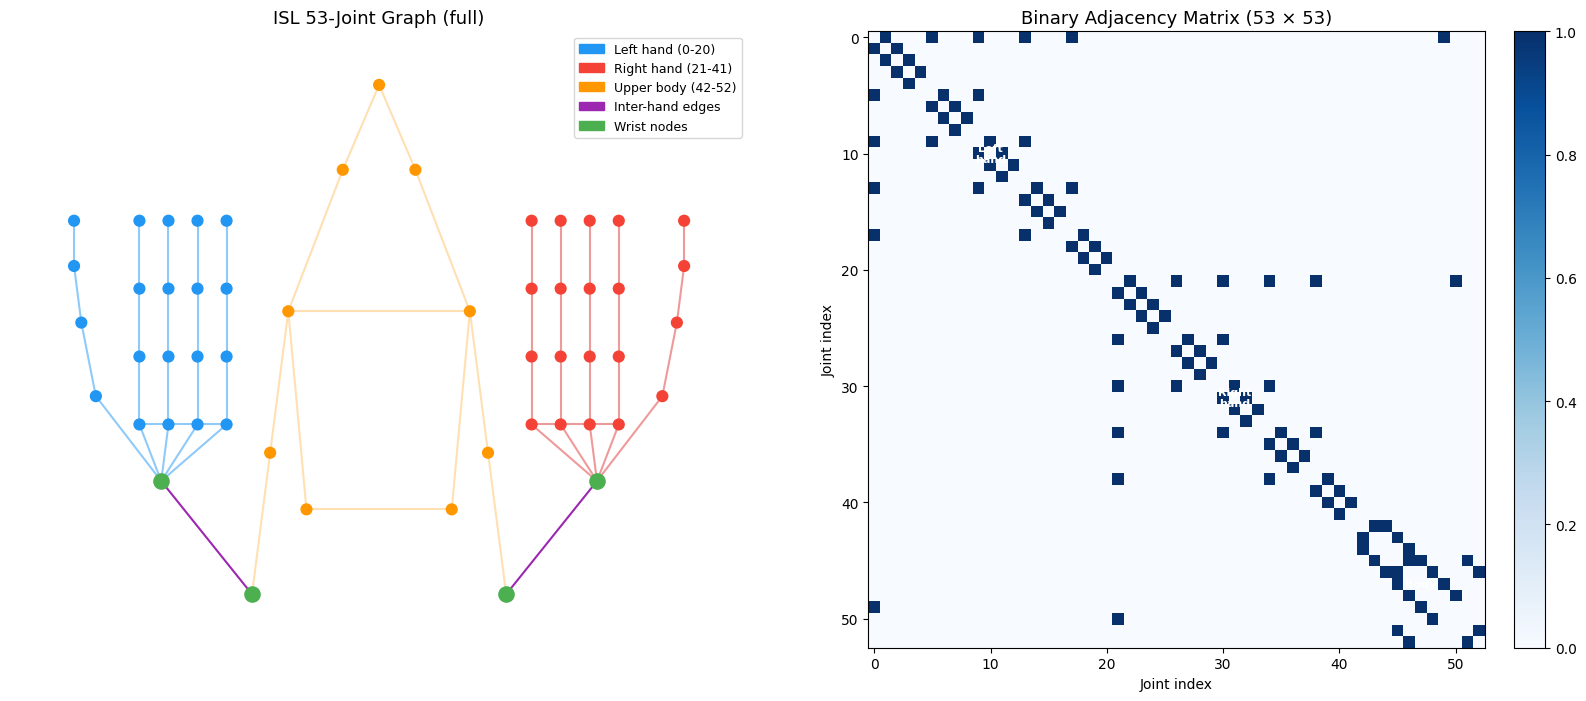

Graph visualization saved.


In [20]:
# ── Visualize the graph ──────────────────────────────────────────────────────
# Build a NetworkX graph and draw with a custom layout that reflects
# the skeleton structure (hands on the sides, body in the middle).

# --- Manual 2D positions reflecting body structure ---
def hand_positions(wrist_x, wrist_y, hand_offset=0.4):
    """Generate rough 2D layout for one hand (21 joints)."""
    pos = {}
    pos[0] = (wrist_x, wrist_y)  # wrist
    # Thumb: tilted
    for k, (dx, dy) in enumerate([(-.18,.15),(-.22,.28),(-.24,.38),(-.24,.46)], start=1):
        pos[k] = (wrist_x + dx * hand_offset, wrist_y + dy)
    # Remaining fingers (index, middle, ring, pinky)
    finger_starts = [5, 9, 13, 17]
    x_offsets     = [-.06, .02, .10, .18]
    for fi, (start, xo) in enumerate(zip(finger_starts, x_offsets)):
        for seg in range(4):
            pos[start + seg] = (wrist_x + xo * hand_offset,
                                 wrist_y + 0.1 + seg * 0.12)
    return pos

# Left hand layout (joints 0-20)
L_pos = hand_positions(-0.6, 0.2, hand_offset=1.0)
L_pos_shifted = {k: v for k, v in L_pos.items()}  # indices already 0-20

# Right hand layout (joints 21-41)
R_pos_raw = hand_positions(0.6, 0.2, hand_offset=-1.0)  # mirror
R_pos_shifted = {k + 21: v for k, v in R_pos_raw.items()}

# Body layout (joints 42-52)
body_pos = {
    42: (0,    0.9),   # nose
    43: (-0.1, 0.75),  # l-ear
    44: (0.1,  0.75),  # r-ear
    45: (-0.25,0.5),   # l-shoulder
    46: (0.25, 0.5),   # r-shoulder
    47: (-0.30,0.25),  # l-elbow
    48: (0.30, 0.25),  # r-elbow
    49: (-0.35,0.0),   # l-wrist (pose)
    50: (0.35, 0.0),   # r-wrist (pose)
    51: (-0.20,0.15),  # l-hip
    52: (0.20, 0.15),  # r-hip
}

pos = {**L_pos_shifted, **R_pos_shifted, **body_pos}

# Build NetworkX graph
G = nx.Graph()
G.add_nodes_from(range(N_JOINTS))
G.add_edges_from(ALL_EDGES)

# Node colours
colors = []
for n in range(N_JOINTS):
    if n <= 20:              colors.append("#2196F3")   # left hand  — blue
    elif n <= 41:            colors.append("#F44336")   # right hand — red
    else:                    colors.append("#FF9800")   # body       — orange

# Edge colours
edge_colors = []
for (u, v) in G.edges():
    if u <= 20 and v <= 20:  edge_colors.append("#90CAF9")
    elif u >= 21 and u <= 41 and v >= 21 and v <= 41:
                             edge_colors.append("#EF9A9A")
    elif (u, v) in INTERHAND_EDGES or (v, u) in INTERHAND_EDGES:
                             edge_colors.append("#9C27B0")   # purple inter-hand
    else:                    edge_colors.append("#FFE0B2")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: full graph
ax = axes[0]
nx.draw_networkx(G, pos=pos, ax=ax,
                 node_size=60, node_color=colors,
                 edge_color=edge_colors, width=1.5,
                 with_labels=False, arrows=False)
# Highlight wrist nodes
for wrist in [0, 21, 49, 50]:
    nx.draw_networkx_nodes(G, pos=pos, ax=ax, nodelist=[wrist],
                           node_size=120, node_color="#4CAF50")
patch_l = mpatches.Patch(color="#2196F3", label="Left hand (0-20)")
patch_r = mpatches.Patch(color="#F44336", label="Right hand (21-41)")
patch_b = mpatches.Patch(color="#FF9800", label="Upper body (42-52)")
patch_i = mpatches.Patch(color="#9C27B0", label="Inter-hand edges")
patch_w = mpatches.Patch(color="#4CAF50", label="Wrist nodes")
ax.legend(handles=[patch_l, patch_r, patch_b, patch_i, patch_w], fontsize=9)
ax.set_title("ISL 53-Joint Graph (full)", fontsize=13)
ax.axis("off")

# Right: adjacency matrix heatmap
ax2 = axes[1]
im = ax2.imshow(A, cmap="Blues", interpolation="nearest")
ax2.set_title("Binary Adjacency Matrix (53 × 53)", fontsize=13)
ax2.set_xlabel("Joint index")
ax2.set_ylabel("Joint index")
# Add region labels
for label, pos_x, pos_y in [
    ("Left\nhand", 10, 10), ("Right\nhand", 31, 31), ("Body", 47, 47)
]:
    ax2.text(pos_x, pos_y, label, ha="center", va="center",
             fontsize=8, color="white", fontweight="bold")
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / "graph_53joints.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Graph visualization saved.")

In [21]:
# ── Verify inter-hand connectivity ───────────────────────────────────────────
# Check that any left-hand joint can reach any right-hand joint through the graph.
G_check = nx.Graph()
G_check.add_edges_from(ALL_EDGES)

left_nodes  = list(range(21))
right_nodes = list(range(21, 42))

path = nx.shortest_path(G_check, source=0, target=21)
print("Shortest path: left hand wrist (0) → right hand wrist (21):")
print("  →".join(map(str, path)))
print(f"  Path length: {len(path) - 1} edges")

# Confirm the graph is connected
if nx.is_connected(G_check):
    print("\nGraph is fully CONNECTED. All 53 joints can communicate.")
else:
    components = list(nx.connected_components(G_check))
    print(f"WARNING: Graph has {len(components)} connected components!")
    for i, comp in enumerate(components):
        print(f"  Component {i}: {sorted(comp)}")

Shortest path: left hand wrist (0) → right hand wrist (21):
0  →49  →47  →45  →46  →48  →50  →21
  Path length: 7 edges

Graph is fully CONNECTED. All 53 joints can communicate.
